# Analyse de l'Éligibilité au Crédit Bancaire
**Projet Data Analyst - Dataset : Loan Prediction (Kaggle)**
---

## Objectif du Projet
L'objectif principal de cette analyse est de déterminer les facteurs influençant l'approbation d'un prêt immobilier. 
En tant que **Data Analyst**, ma mission est de :
1. Auditer la qualité des dossiers clients (Nettoyage).
2. Identifier les variables critiques (Revenus, Historique de crédit, etc.) qui impactent la décision.
3. Fournir des recommandations métier pour optimiser le processus d'octroi de crédit.

## Description du Dataset
Le dataset contient **614 observations** et **13 variables**. Chaque ligne représente un client ayant déposé une demande de prêt. 
Les informations incluent des données démographiques (genre, statut marital), financières (revenu, montant du prêt) et historiques (crédits passés).

**Lien du Dataset** : https://www.kaggle.com/datasets/ninzaami/loan-predication/data



## **Axe 1 : Audit et Nettoyage des Données (Data Cleaning)**


In [91]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

loan_data = pd.read_csv("Loan_data.csv")



In [74]:
loan_data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [75]:
## On calcule le pourcentage de ligne incomplètes

nb_lignes_vides = loan_data.isnull().any(axis=1).sum()
pourcentage_vides=(nb_lignes_vides / len(loan_data)) * 100

print(f"Lignes avec des données manquantes : {nb_lignes_vides}")
print(f"Pourcentage d'impact : {pourcentage_vides:.2f}%")

Lignes avec des données manquantes : 134
Pourcentage d'impact : 21.82%


Une analyse préliminaire via **df.isnull().sum()** montre que le dataset comporte plusieurs valeurs manquantes. Un traitement est indispensable car :

- Les algorithmes et calculs statistiques ne gèrent pas les valeurs NaN.

- Supprimer les lignes incomplètes nous ferait perdre 21.82% du dataset (sois près d'un quart de nos clients), ce qui réduirait la représentativité de l'échantillon.

Nous allons donc nettoyer chaques lignes pour garder la représentativité.

In [76]:
loan_data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [77]:
## Nettoyage du Dataset

## On utilise la mode pour les colonnes à variables binaires
cols_a_nettoyer_mode = ['Gender', 'Married', 'Dependents', 'Self_Employed', 'Credit_History']

for cols in cols_a_nettoyer_mode:
    loan_data[cols] = loan_data[cols].fillna(loan_data[cols].mode()[0])
    
## On utilise la médiane pour les variables à valeurs numériques

cols_a_nettoyer_med = ['LoanAmount', 'Loan_Amount_Term']

for cols in cols_a_nettoyer_med:
    loan_data[cols] = loan_data[cols].fillna(loan_data[cols].median())
    
## On vérifie si les données ont bien été nettoyées
loan_data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

On peut voir que le nettoyage est terminé. Le dataset est désormais "Production-Ready".

## **Axe 2 : Analyse Exploratoire des Données (EDA)**

Le nettoyage des données étant finalisé (0 valeur manquante, intégrité des variables financières assurée), 
nous pouvons maintenant passer à l'analyse pour extraire des insights métier.

L'objectif de cette section est de répondre à la problématique centrale : 
**Quels sont les facteurs déterminants qui poussent la banque à accepter ou refuser un crédit ?**

Nous allons explorer successivement :
1. La répartition globale des décisions (KPI de référence).
2. L'influence des variables catégorielles (Historique de crédit, Mariage).
3. L'impact des variables financières (Revenu total du foyer, Montant du prêt).

# 1. La répartition globale des décisions (KPI de référence).

On commence par déterminer **le taux d'Approbation**. On fait donc une analyse univarié : on ne regarde qu'une seul colonne pour comprendre la "température" globale de l'activité.

Le but est de montrer visuellement si la banque est plutôt "généreuse" ou "stricte".



In [78]:
loan_data['Loan_Status'].value_counts(normalize=True)

Loan_Status
Y    0.687296
N    0.312704
Name: proportion, dtype: float64

On peut voir que sur tous les dossiers présents, **68,7 %** ont vu leur demande de prêt être acceptée.

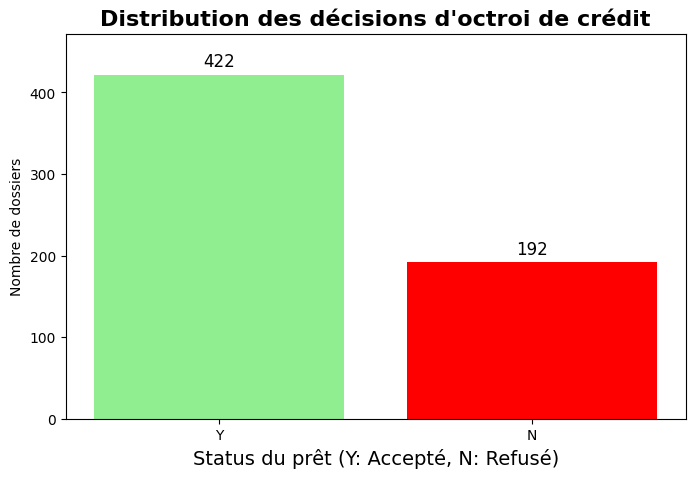

In [79]:
# Préparation des données : on compte les occurences
status_counts = loan_data['Loan_Status'].value_counts()

# Création du graphique
plt.figure(figsize=(8, 5))
bars = plt.bar(status_counts.index, status_counts.values, color=["lightgreen", "red"])

# Ajout d'étiquettes pour avoir la valeur précise
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 5, yval, 
             ha='center', va='bottom', fontsize=12)

# Personnalisation
plt.title("Distribution des décisions d'octroi de crédit", fontsize=16, fontweight='bold')
plt.xlabel("Status du prêt (Y: Accepté, N: Refusé)", fontsize=14)
plt.ylabel("Nombre de dossiers")
plt.xticks(rotation=0)
plt.ylim(0, status_counts.max() + 50)
plt.show()


Cette première analyse nous permet de dresser un état des lieux de l'activité d'octroi de crédit :

- **Volume d'approbation :** on peut voir que sur les **614 dossiers étudiés**, **422** ont reçu une réponse favorable soit **68,7%**

- **Profil de la demande :** on peut voir que les demandeurs sont majoritairement en adéquation avec les critères de la banque.

- **Point d'attention :** les **31,3 % de refus (192 dossiers)** sont non négligeables L'enjeu est de déterminer les causes de ces rejets et s'ils sont concentrés sur une partie spécifique de la population.


L'objectif est donc de déterminer les facteurs discrimiants

## 2. L'influence des variables catégorielles (Historique de crédit, Mariage).

Maintenant que nous avons le **taux d'approbation**, nous cherchons à savoir si la banque s'est basée sur **l'Historique de Crédit** pour l'octroiement des prêts.

In [85]:
croisement = pd.crosstab(loan_data['Credit_History'], loan_data['Loan_Status'], normalize='index') * 100

print(croisement)

Loan_Status             N          Y
Credit_History                      
0.0             92.134831   7.865169
1.0             20.952381  79.047619


L'analyse croisée met en évidence une **disparité majeure** de traitement selon le profil de crédit du demandeur :

- **Le Mur du Risque (Historique 0.0) :** Avec un taux de refus massif de **92,13 %**, l'absence d'historique de crédit est le principal facteur d'exclusion. Seule une infime minorité (**7,86 %**) parvient à sécuriser un prêt, probablement grâce à des garanties externes exceptionnelles.

- **Le Levier d'Approbation (Historique 1.0) :** À l'inverse, posséder un historique sain multiplie par 10 les chances de succès, avec **79,04 %** d'acceptation. Néanmoins, les **20,95 %** de refus restants prouvent que la banque ne valide pas "aveuglément" : d'autres critères financiers viennent arbitrer la décision finale.

**Bilan :** L'historique de crédit n'est pas une simple information, c'est le **filtre de confiance** indispensable pour accéder à l'examen financier détaillé du dossier.

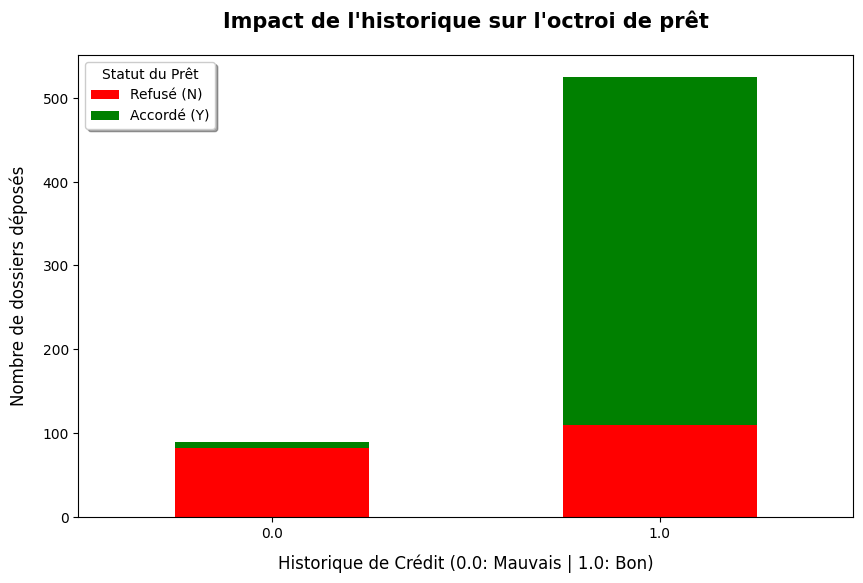

In [82]:
# Calcul de croisement
croisement = pd.crosstab(loan_data['Credit_History'], loan_data['Loan_Status'])

# Création de ma figure 
fig, ax = plt.subplots(figsize=(10,6))

# Tracé
croisement.plot(kind='bar',
                stacked=True,
                color=['red', 'green'],
                ax=ax)
plt.title("Impact de l'historique sur l'octroi de prêt", fontsize=15, fontweight='bold', pad=20)
plt.xlabel("Historique de Crédit (0.0: Mauvais | 1.0: Bon)", fontsize=12, labelpad=10)
plt.ylabel("Nombre de dossiers déposés", fontsize=12, labelpad=10)
plt.xticks(rotation=0)
plt.legend(title="Statut du Prêt", labels=["Refusé (N)", "Accordé (Y)"], frameon=True, shadow=True)
plt.show()


### Conclusion du Croisement : Historique de Crédit vs Décision

L'analyse bivariée réalisée via le tableau croisé et sa visualisation met en lumière une **vérité métier incontournable** :

- **Un prédicteur binaire quasi-parfait :** L'historique de crédit n'est pas un simple critère, c'est une **condition sine qua non**. Le taux d'approbation passe de **7,8 %** (sans historique) à **79 %** (avec historique).
- **Gestion stricte du risque :** La banque refuse de s'engager auprès de profils n'ayant pas fait leurs preuves par le passé. Cela traduit une politique d'octroi **conservative** et prudente.
- **Volume d'opportunité :** Bien que la majorité des clients aient un bon historique, le groupe "sans historique" représente un **manque à gagner potentiel**. 

**Insight Stratégique :** Si le but de la banque est de croître, elle devra développer des outils de scoring alternatifs pour analyser la solvabilité de ceux qui n'ont pas encore d'historique de crédit (jeunes actifs par exemple).

# 3. L'impact des variables financières (Revenu total du foyer, Montant du prêt).

Après avoir vu que le passé (l'historique) est déterminant, nous analysons si le présent (le revenu) l'est tout autant. Nous allons créer une nouvelle variable, le Revenu Total (Demandeur + Co-demandeur), car c'est ainsi que les banques calculent réellement la capacité de remboursement.

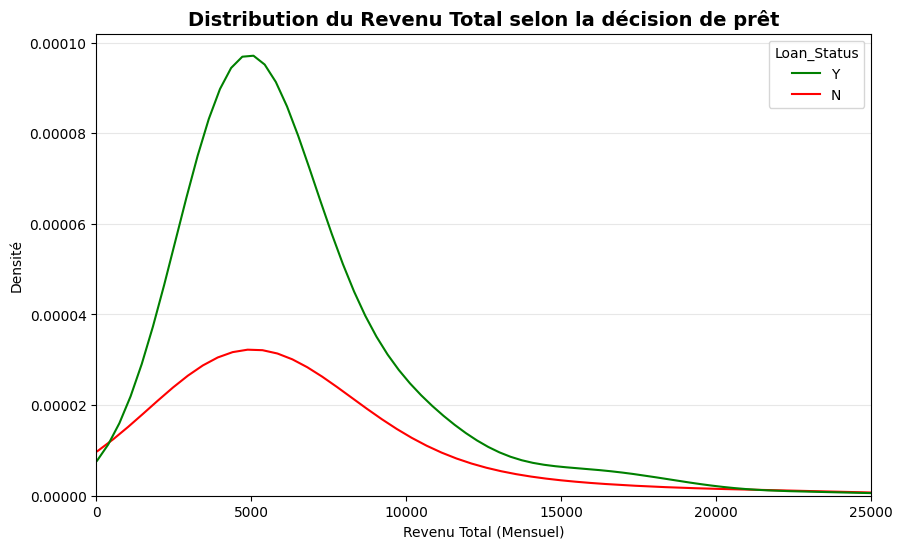

In [98]:
# Création de la variable 'Total_Income'
loan_data['Total_Income'] = loan_data['ApplicantIncome'] + loan_data['CoapplicantIncome']

# Visualisation de la distribution avec un histogramme superposé
plt.figure(figsize=(10, 6))

# On trace la distribution des revenus pour les prêts acceptés et refusés
sns.kdeplot(data=loan_data, x='Total_Income', hue='Loan_Status', palette=['green', 'red'])

# Personnalisation
plt.title("Distribution du Revenu Total selon la décision de prêt", fontsize=14, fontweight='bold')
plt.xlabel("Revenu Total (Mensuel)")
plt.ylabel("Densité")
plt.xlim(0, 25000) # On limite l'axe pour mieux voir la zone où se concentre 95% de la population
plt.grid(axis='y', alpha=0.3)

plt.show()

## Conclusion Finale : La Logique Décisionnelle Décodée
L'analyse exploratoire (EDA) des 614 dossiers révèle que l'octroi de crédit n'est pas le fruit d'un facteur unique, mais d'une hiérarchie de filtres très stricte qui définit la gestion du risque de l'établissement.

**L'Historique de Crédit : Le "Sésame" Indispensable**

C'est le facteur de décision n°1. L'historique de crédit agit comme un verrou de sécurité comportemental :

- Taux de refus de 92,13 % pour les profils sans antécédents (Credit_History = 0).

- Sans cette preuve de fiabilité passée, le dossier est écarté d'emblée, quel que soit le niveau de richesse du demandeur.

**Le Seuil des 5 000 : La Frontière de Solvabilité**

L'analyse de la densité a permis de mettre en lumière un point de bascule critique au niveau du revenu total :

- Autour de 5 000 : C'est la zone de tension maximale. C'est ici que l'écart entre les "acceptés" et les "refusés" est le plus significatif. Ce chiffre représente le seuil de sécurité minimal pour garantir un reste-à-vivre suffisant.

- Levier d'approbation : Dès que ce cap est franchi, la probabilité d'accord augmente radicalement. La banque cherche avant tout à valider la viabilité financière de la classe moyenne.

**La Saturation des Revenus (10 000 et +)**

L'influence du revenu n'est pas linéaire ; elle finit par stagner :

- À 10 000 : L'avantage du revenu est encore présent mais son pouvoir discriminant diminue.

- À 20 000 : Les courbes se rejoignent et le revenu devient un critère neutre. La solvabilité étant considérée comme acquise, la banque revient exclusivement à une analyse du risque comportemental (l'historique).